In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('heart.csv')

In [6]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [7]:
df.shape

(918, 12)

In [8]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [10]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [11]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

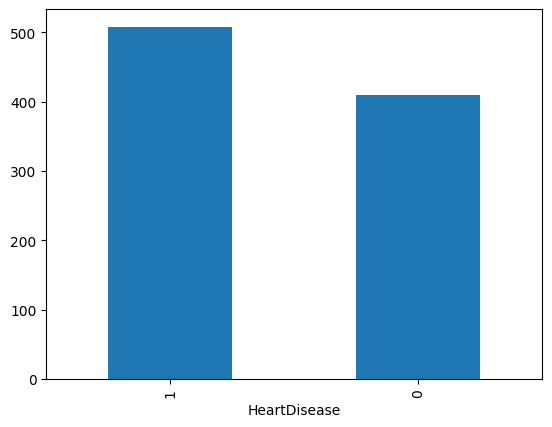

In [13]:
df['HeartDisease'].value_counts().plot(kind='bar')

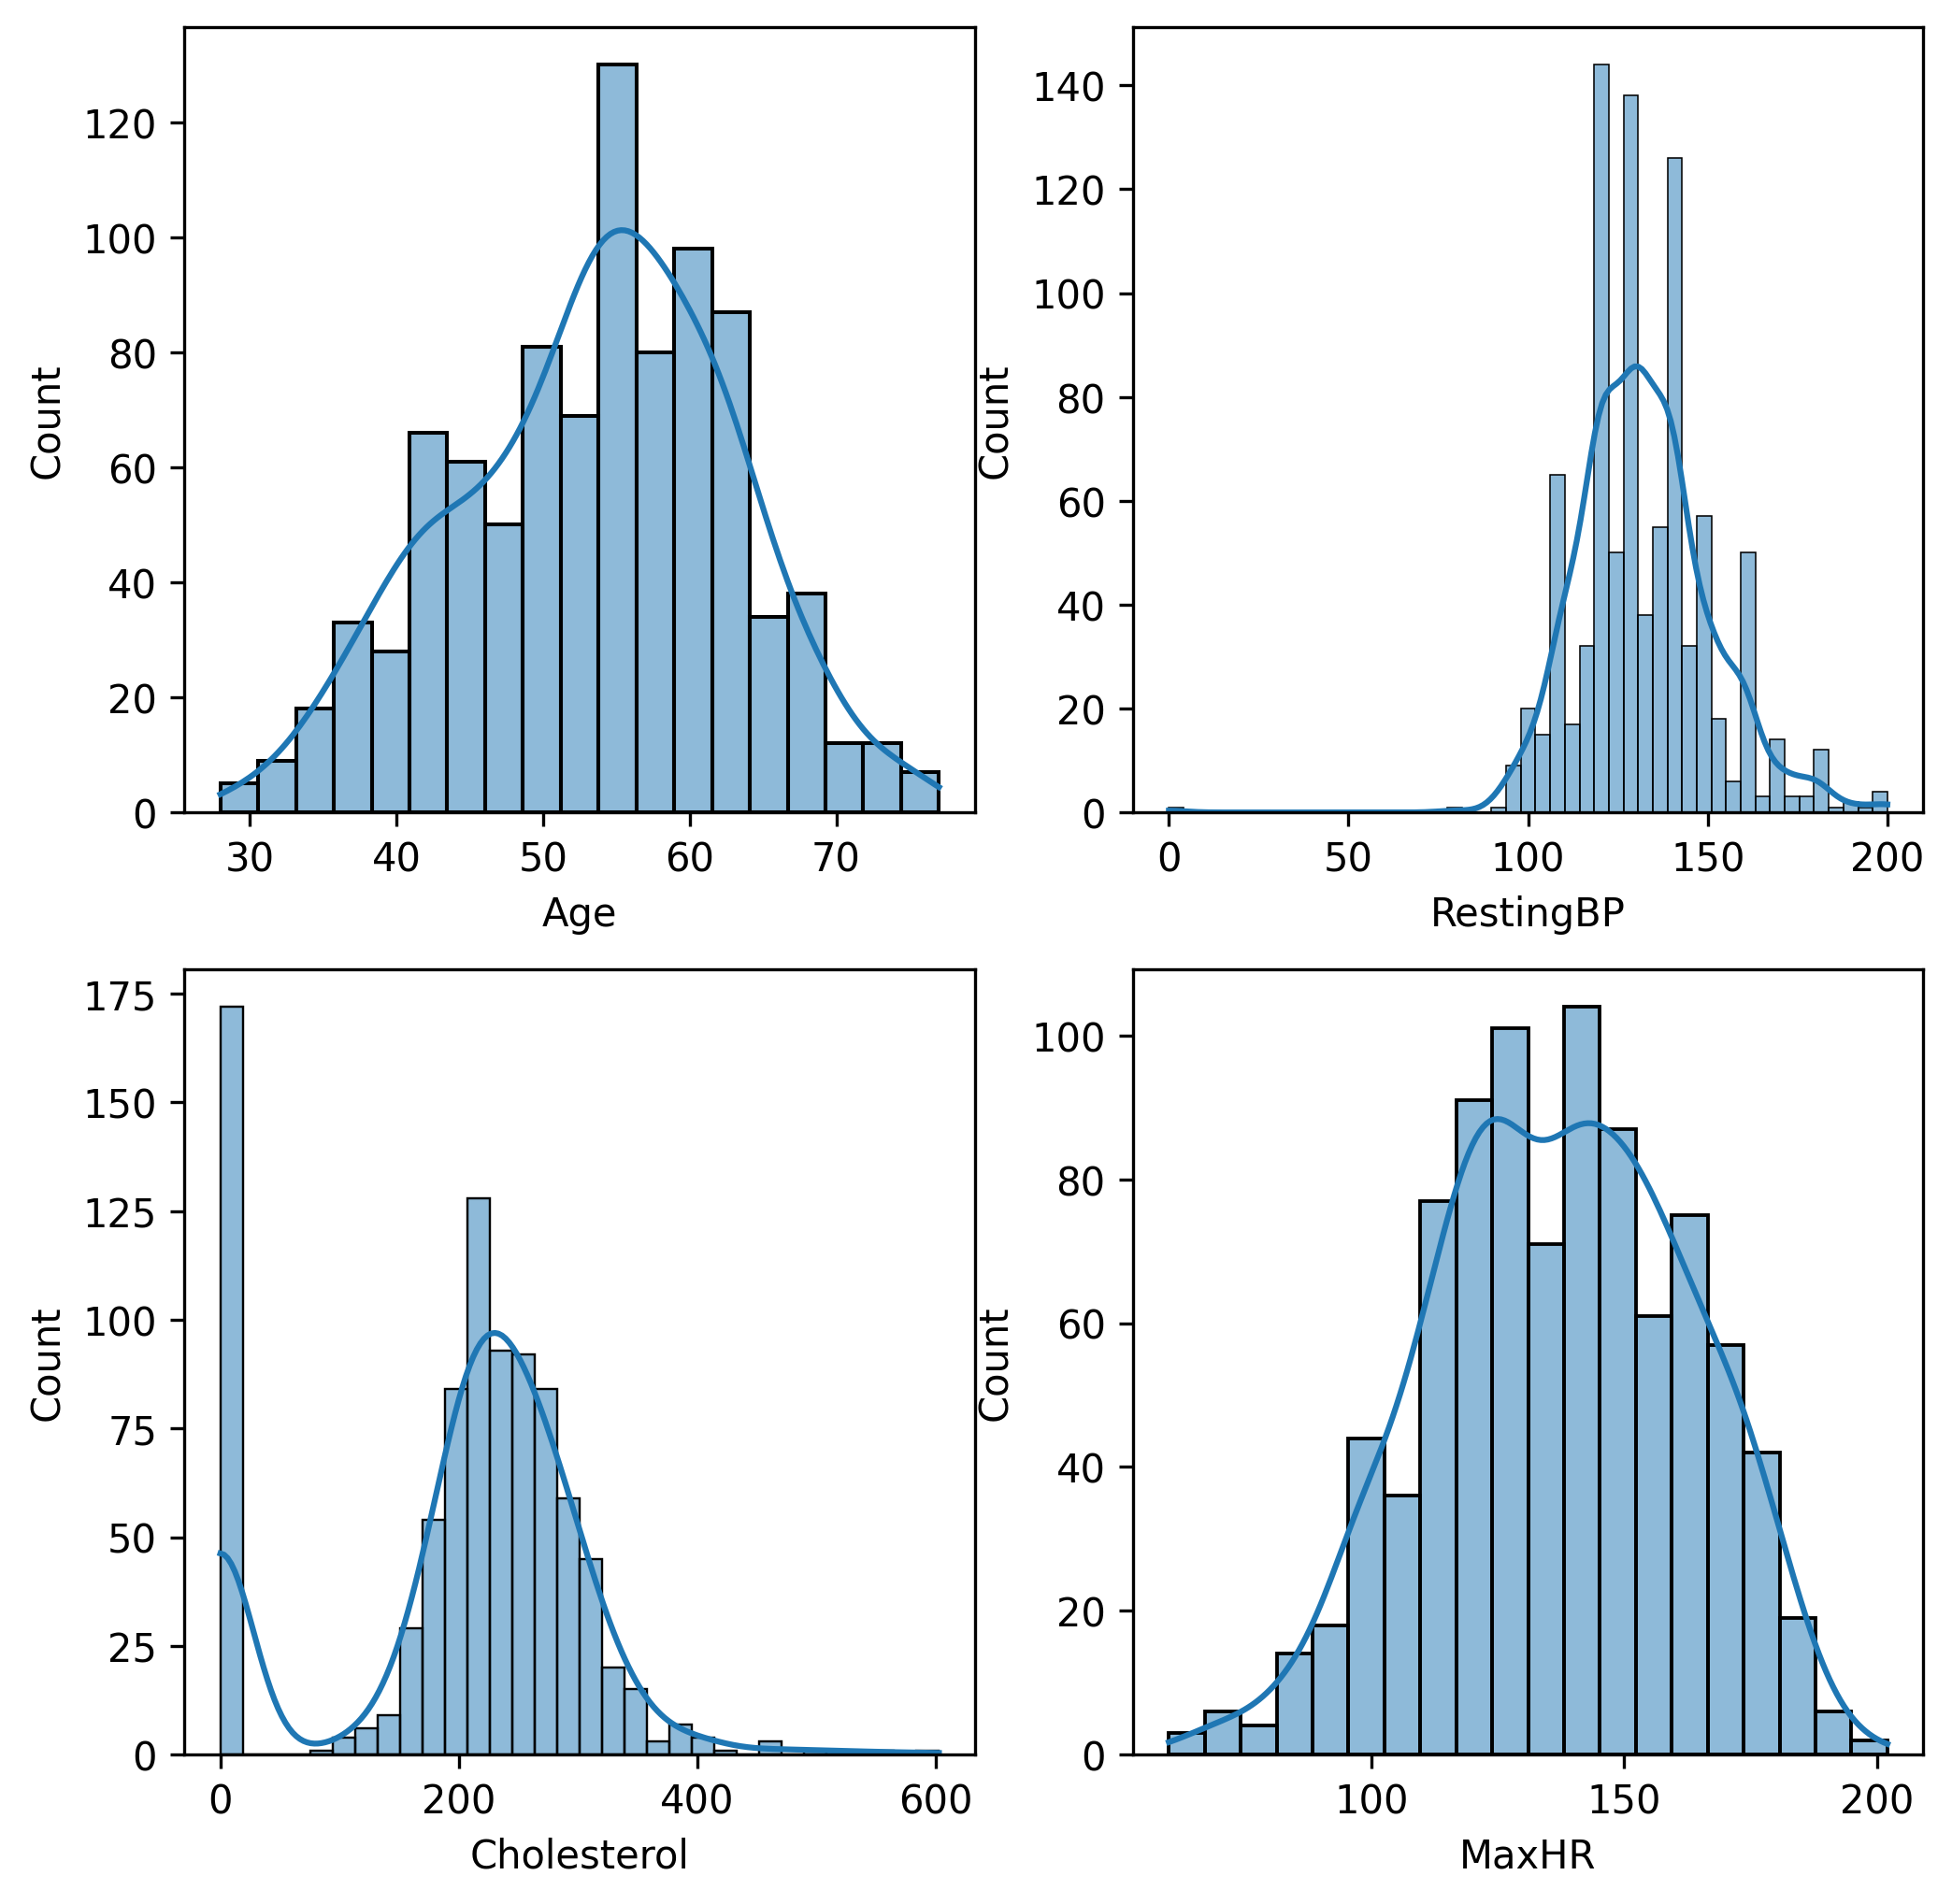

In [14]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var], kde=True)

plt.figure(figsize=(8,8),dpi=300)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

In [15]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [16]:
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [17]:
ch_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,ch_mean)
df['RestingBP'] = df['RestingBP'].round(2)

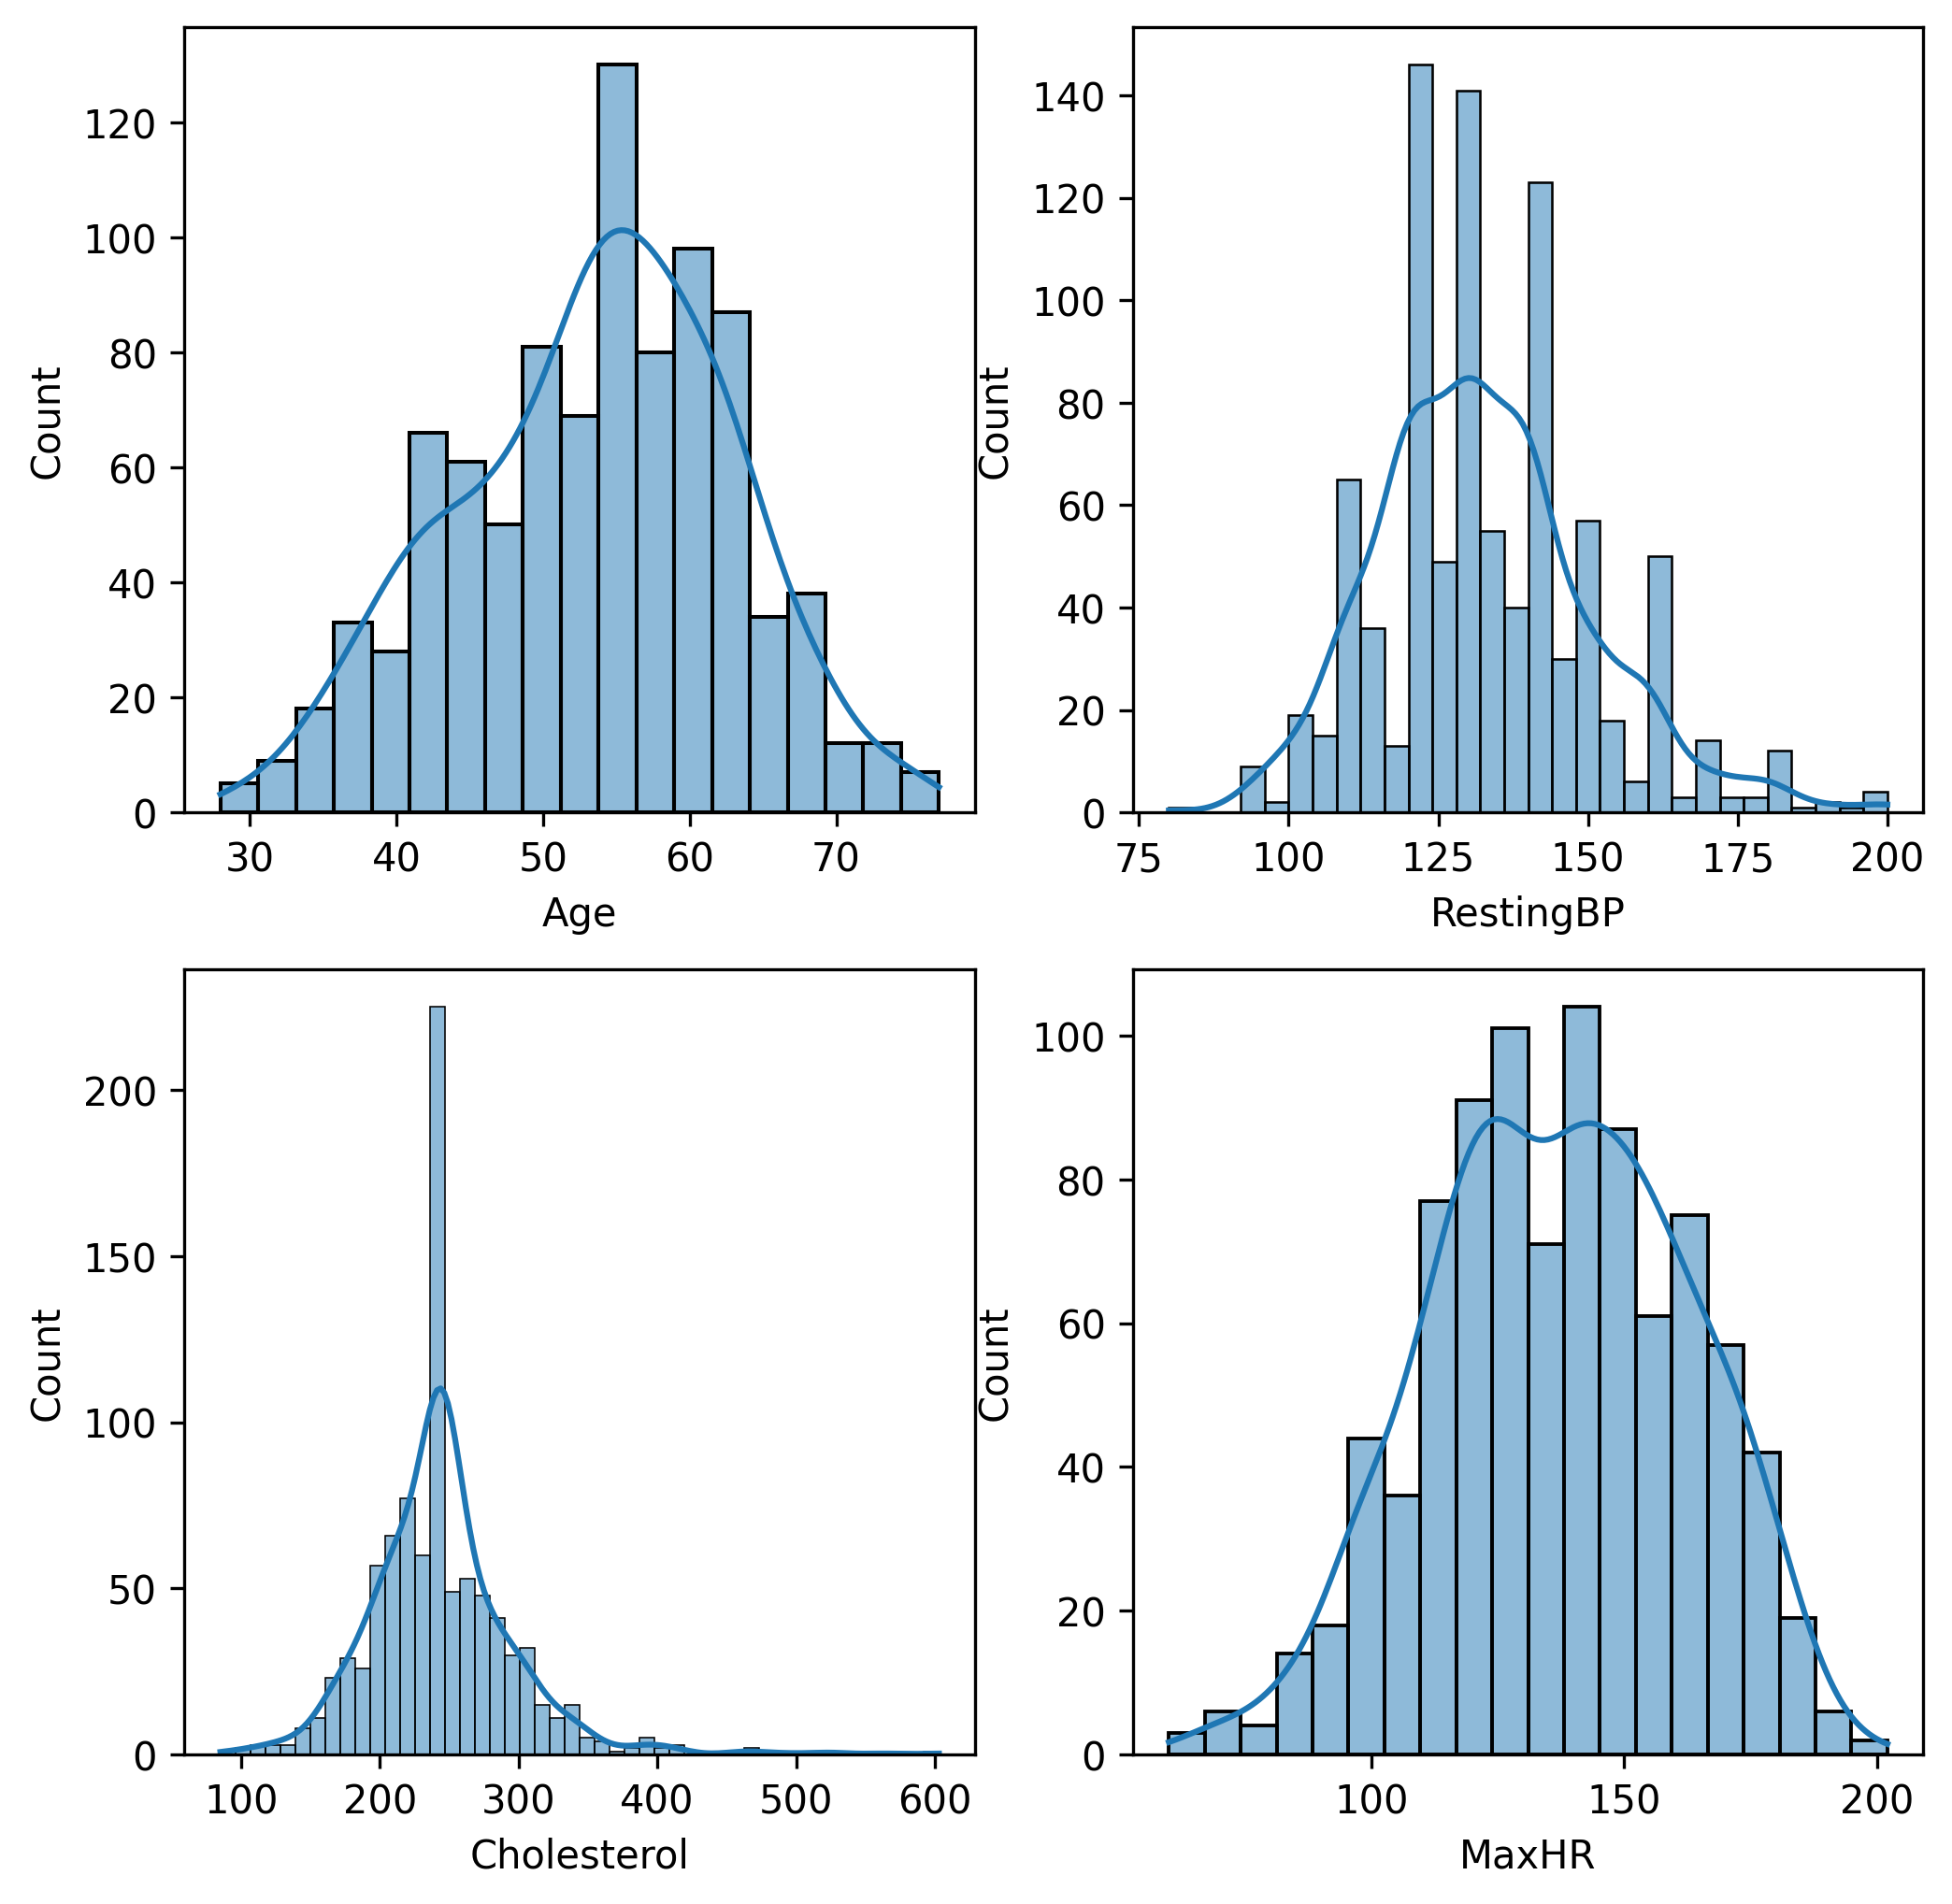

In [18]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var], kde=True)

plt.figure(figsize=(8,8),dpi=300)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

<Axes: xlabel='Sex', ylabel='count'>

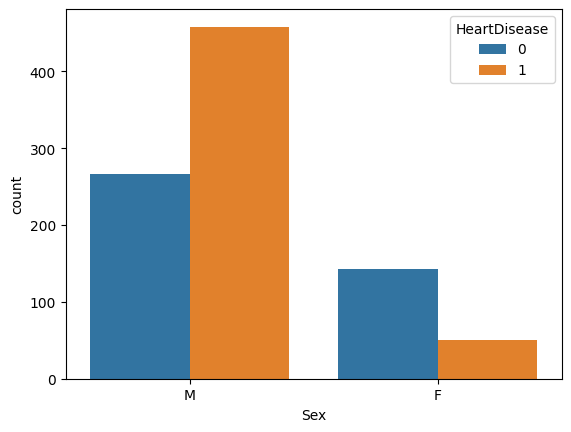

In [25]:
sns.countplot(x = df['Sex'],hue = df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

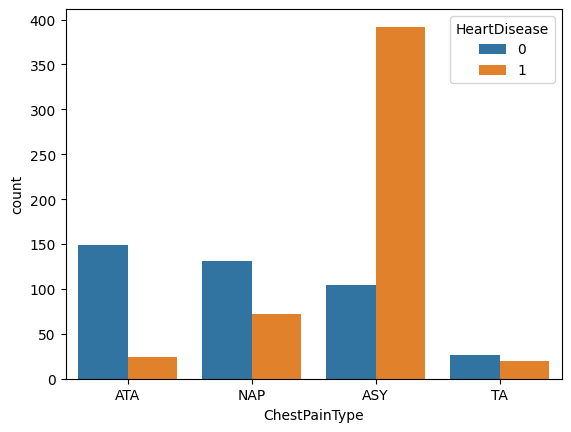

In [23]:
sns.countplot(x = df['ChestPainType'],hue = df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

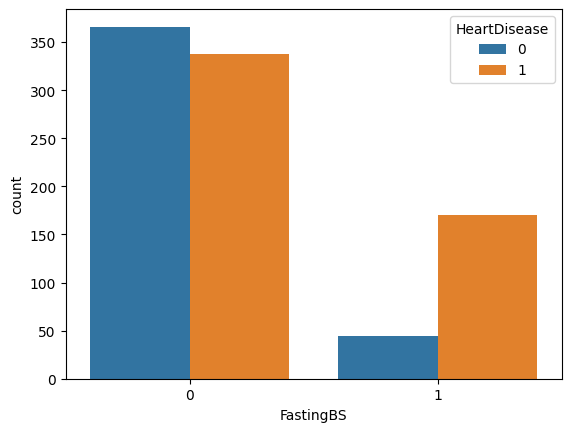

In [28]:
sns.countplot(x = df['FastingBS'],hue = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

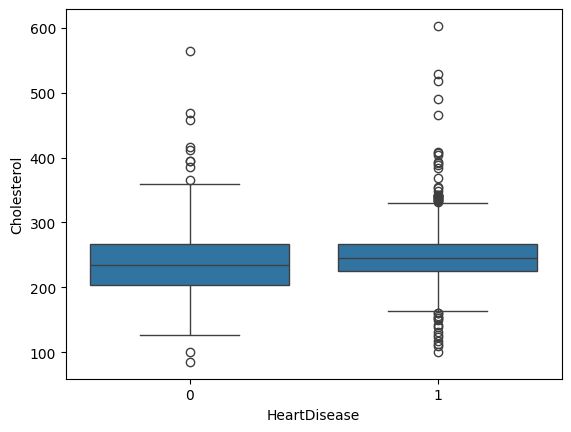

In [30]:
sns.boxplot(x = 'HeartDisease', y = 'Cholesterol',data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

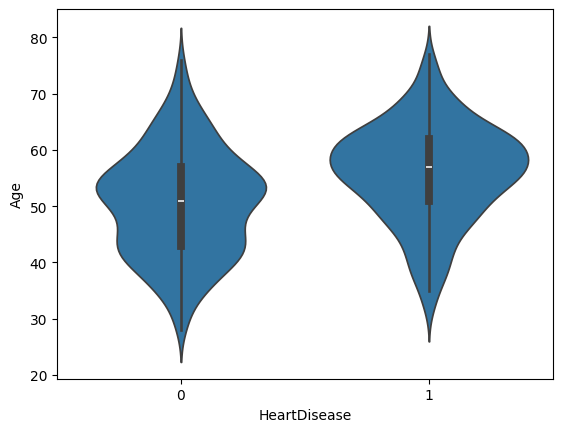

In [33]:
sns.violinplot(x = 'HeartDisease', y = 'Age',data = df)

<Axes: >

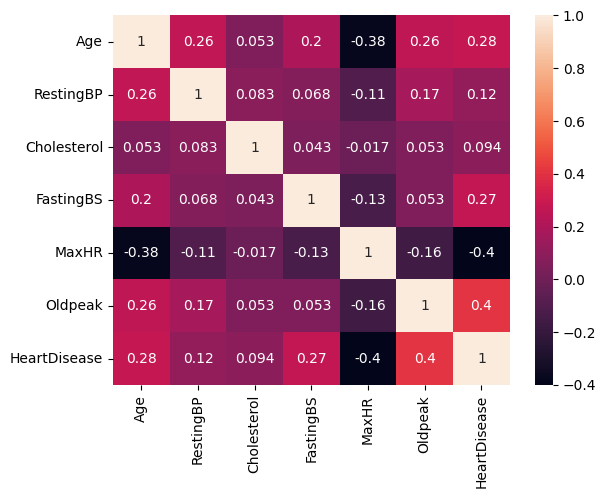

In [34]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Data Preprocessing and Cleaning

In [35]:
df_encode = pd.get_dummies(df,drop_first=True)

In [36]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [37]:
df_encode = df_encode.astype(int)

In [38]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [40]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['RestingBP','Age','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()

df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])

In [42]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [44]:
from scipy.stats import pearsonr

# -----------------------------
# Pearson Correlation Calculation
# -----------------------------

# List of features to check against target
selected_features = [
    'Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
    'Oldpeak', 'Sex_M',
    'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
    'ST_Slope_Flat','ST_Slope_Up'
]

correlations = {
    feature: pearsonr(df_encode[feature], df_encode['HeartDisease'])[0]
    for feature in selected_features
} 

correlation_df = pd.DataFrame(list(correlations.items()),columns = ['Feature', 'Pearson Correlaton'])
correlation_df.sort_values(by='Pearson Correlaton', ascending=False)

                           

,Feature,Pearson Correlaton
10,ST_Slope_Flat,0.554134
5,Oldpeak,0.392385
6,Sex_M,0.305445
0,Age,0.282039
3,FastingBS,0.267291
1,RestingBP,0.117909
2,Cholesterol,0.092586
9,ChestPainType_TA,-0.054790
8,ChestPainType_NAP,-0.212964
4,MaxHR,-0.400421


In [45]:
cat_features = [
     'Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
    'Oldpeak', 'Sex_M',
    'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
    'ST_Slope_Flat','ST_Slope_Up'
]

In [50]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

# HeartDisease ko categorical hi rehne do
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_encode[col], df_encode['HeartDisease'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T.sort_values(by='p_value')
print(chi2_df)

                  chi2_statistic   p_value                    Decision
ST_Slope_Up           352.823905       0.0  Reject Null (Keep Feature)
ST_Slope_Flat         279.659914       0.0  Reject Null (Keep Feature)
Oldpeak               182.849456       0.0  Reject Null (Keep Feature)
ChestPainType_ATA     146.236323       0.0  Reject Null (Keep Feature)
Sex_M                  84.145101       0.0  Reject Null (Keep Feature)
FastingBS              64.320679       0.0  Reject Null (Keep Feature)
MaxHR                 241.320595       0.0  Reject Null (Keep Feature)
ChestPainType_NAP      40.608711       0.0  Reject Null (Keep Feature)
Age                   125.365667       0.0  Reject Null (Keep Feature)
Cholesterol           329.859669  0.000002  Reject Null (Keep Feature)
RestingBP              92.318868   0.01459  Reject Null (Keep Feature)
ChestPainType_TA        2.273802  0.131577  Accept Null (Drop Feature)


In [53]:
final_df_encode = df_encode[['ST_Slope_Up','ST_Slope_Flat','Oldpeak','ChestPainType_ATA',
                             'Sex_M','FastingBS','MaxHR','ChestPainType_NAP','Age',
                             'Cholesterol','RestingBP']]

In [54]:
final_df_encode

,ST_Slope_Up,ST_Slope_Flat,Oldpeak,ChestPainType_ATA,Sex_M,FastingBS,MaxHR,ChestPainType_NAP,Age,Cholesterol,RestingBP
0,1,0,-0.727592,1,1,0,1.382928,0,-1.433140,0.834754,0.414885
1,0,1,0.282891,0,0,0,0.754157,1,-0.478484,-1.210675,1.527224
2,1,0,-0.727592,1,1,0,-1.525138,0,-1.751359,0.722161,-0.141284
3,0,1,0.282891,0,0,0,-1.132156,0,-0.584556,-0.572651,0.303651
4,1,0,-0.727592,0,1,0,-0.581981,1,0.051881,-0.929194,0.971054
...,...,...,...,...,...,...,...,...,...,...,...
913,0,1,0.282891,0,1,0,-0.188999,0,-0.902775,0.365619,-1.253622
914,0,1,2.303858,0,1,1,0.164684,0,1.536902,-0.966725,0.637353
915,0,1,0.282891,0,1,0,-0.857069,0,0.370100,-2.130180,-0.141284
916,0,1,-0.727592,1,0,0,1.461525,0,0.370100,-0.159813,-0.141284
